# 06 — Model Validation

Validation asks whether the period-specific model and Monte Carlo procedure reproduce **withheld historical observations** that were not used for calibration. Each period uses a chronological 80/20 split.

The most important distinction is between:
- **absolute-level accuracy** in MW, and
- **normalized-profile accuracy** (the shape/timing of the 24-hour curve).

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src" / "data_preparation.py").is_file():
    project_root = project_root.parent
if not (project_root / "src" / "data_preparation.py").is_file():
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import PERIOD_ORDER
figures_dir = project_root / "figures"
results_dir = project_root / "results"
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

from src.modeling import fit_period_model
from src.validation import validate_model
from src.normalization import add_daily_normalization

df = pd.read_csv(project_root / "data/processed/luzon_hourly_clean.csv", parse_dates=["date", "datetime"])
bundles = {p: fit_period_model(df, p) for p in PERIOD_ORDER}
validation_metrics = []
validation_sims = {}
for i, period in enumerate(PERIOD_ORDER):
    b = bundles[period]
    metrics, sim = validate_model(b.model, b.residual_library, b.test, n_runs=1000, seed=142+i, period=period)
    metrics.insert(0, "period", period)
    validation_metrics.append(metrics)
    validation_sims[period] = sim
validation = pd.concat(validation_metrics, ignore_index=True)
validation

,period,metric,actual,simulated
0,Pre-pandemic,overall_mean_mw,8430.591134,7797.733542
1,Pre-pandemic,overall_std_mw,1191.049559,1150.514603
2,Pre-pandemic,mean_daily_peak_mw,9675.922374,9014.350000
3,Pre-pandemic,mean_daily_variability_mw,978.708642,959.511251
4,Pre-pandemic,modal_peak_hour,13.000000,13.000000
5,Pre-pandemic,absolute_24h_profile_rmse_mw,0.000000,633.571272
6,Pre-pandemic,normalized_24h_profile_rmse,0.000000,0.007752
7,Pandemic,overall_mean_mw,8295.979452,7911.149792
8,Pandemic,overall_std_mw,1051.065247,1112.422901
9,Pandemic,mean_daily_peak_mw,9442.465753,9054.091000


In [3]:
def metric_value(period, metric, col):
    return float(validation[(validation.period == period) & (validation.metric == metric)][col].iloc[0])

rows = []
for period in PERIOD_ORDER:
    actual_mean = metric_value(period, "overall_mean_mw", "actual")
    sim_mean = metric_value(period, "overall_mean_mw", "simulated")
    actual_peak = metric_value(period, "mean_daily_peak_mw", "actual")
    sim_peak = metric_value(period, "mean_daily_peak_mw", "simulated")
    actual_sd = metric_value(period, "overall_std_mw", "actual")
    sim_sd = metric_value(period, "overall_std_mw", "simulated")
    actual_var = metric_value(period, "mean_daily_variability_mw", "actual")
    sim_var = metric_value(period, "mean_daily_variability_mw", "simulated")
    rows.append({
        "period": period,
        "mean_actual_MW": actual_mean,
        "mean_simulated_MW": sim_mean,
        "mean_bias_pct": (sim_mean/actual_mean-1)*100,
        "peak_actual_MW": actual_peak,
        "peak_simulated_MW": sim_peak,
        "peak_bias_pct": (sim_peak/actual_peak-1)*100,
        "overall_SD_bias_pct": (sim_sd/actual_sd-1)*100,
        "within_day_variability_bias_pct": (sim_var/actual_var-1)*100,
        "actual_modal_NGCP_Hour_No": int(metric_value(period, "modal_peak_hour", "actual"))+1,
        "sim_modal_NGCP_Hour_No": int(metric_value(period, "modal_peak_hour", "simulated"))+1,
        "absolute_profile_RMSE_MW": metric_value(period, "absolute_24h_profile_rmse_mw", "simulated"),
        "normalized_profile_RMSE": metric_value(period, "normalized_24h_profile_rmse", "simulated"),
    })
validation_summary = pd.DataFrame(rows)
validation_summary.round(4)

,period,mean_actual_MW,mean_simulated_MW,mean_bias_pct,peak_actual_MW,peak_simulated_MW,peak_bias_pct,overall_SD_bias_pct,within_day_variability_bias_pct,actual_modal_NGCP_Hour_No,sim_modal_NGCP_Hour_No,absolute_profile_RMSE_MW,normalized_profile_RMSE
0,Pre-pandemic,8430.5911,7797.7335,-7.5067,9675.9224,9014.350,-6.8373,-3.4033,-1.9615,14,14,633.5713,0.0078
1,Pandemic,8295.9795,7911.1498,-4.6387,9442.4658,9054.091,-4.1131,5.8377,-1.8941,14,14,388.8319,0.0060
2,Recovery,9893.5816,9167.7664,-7.3362,11239.8438,10456.561,-6.9688,-5.6948,-6.5139,14,14,731.0512,0.0057


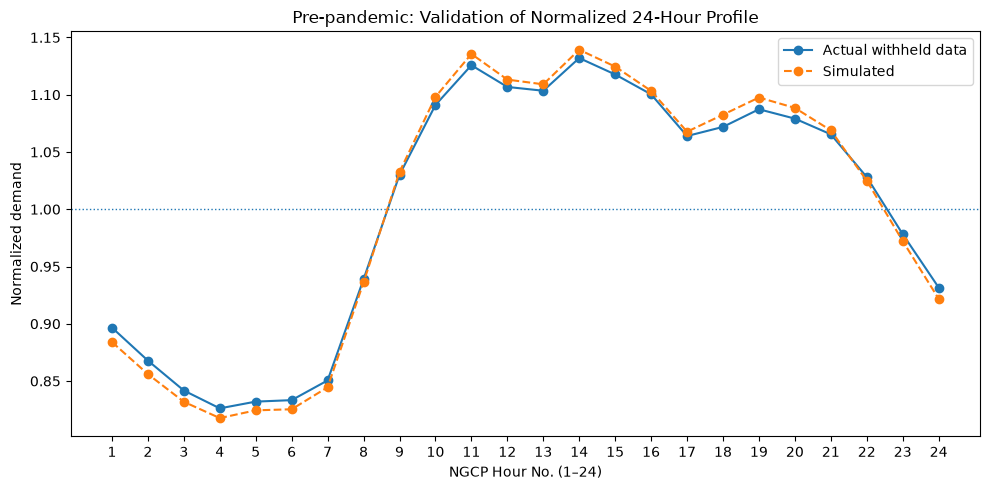

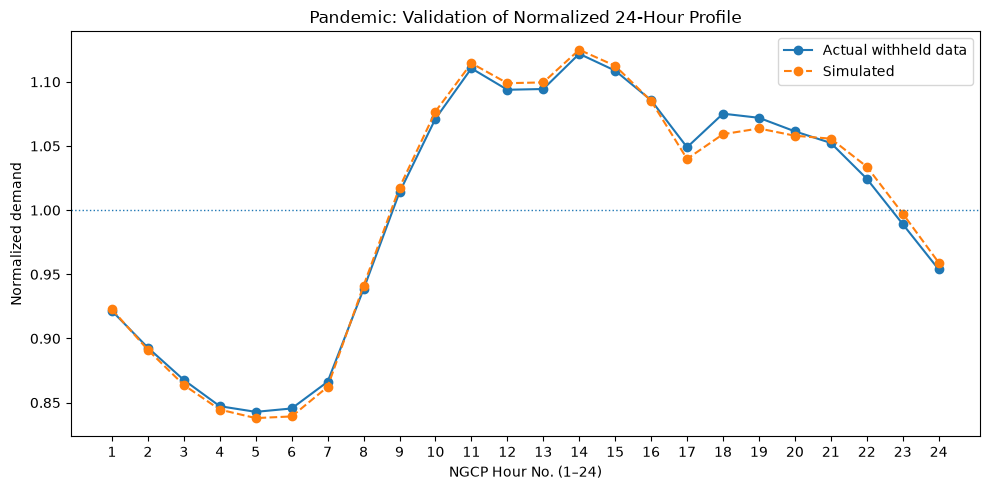

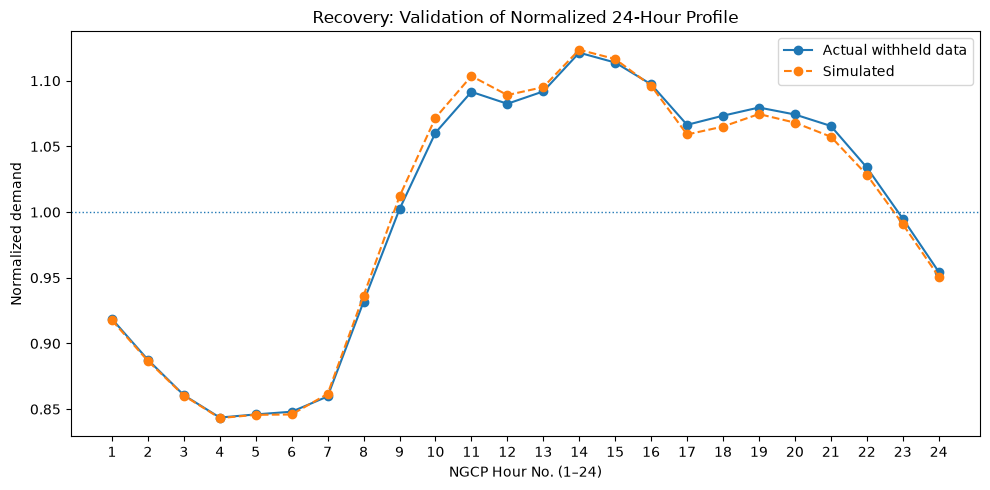

In [4]:
for period in PERIOD_ORDER:
    b = bundles[period]
    actual = add_daily_normalization(b.test.dropna(subset=["demand_mw"]))
    sim = validation_sims[period]
    a = actual.groupby("hour")["normalized_demand"].mean()
    s = sim.groupby("hour")["normalized_demand"].mean()
    plt.figure(figsize=(10, 5))
    plt.plot(a.index + 1, a.values, marker="o", label="Actual withheld data")
    plt.plot(s.index + 1, s.values, marker="o", linestyle="--", label="Simulated")
    plt.axhline(1.0, linewidth=1, linestyle=":")
    plt.title(f"{period}: Validation of Normalized 24-Hour Profile")
    plt.xlabel("NGCP Hour No. (1–24)")
    plt.ylabel("Normalized demand")
    plt.xticks(range(1, 25))
    plt.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / f"validation_normalized_{period.lower().replace('-', '_').replace(' ', '_')}.png", dpi=160)
    plt.show()

In [5]:
validation.to_csv(results_dir / "validation_metrics.csv", index=False)
validation_summary.to_csv(results_dir / "validation_summary.csv", index=False)
print("VALIDATION INTERPRETATION")
for _, r in validation_summary.iterrows():
    print(f"- {r['period']}: mean bias={r['mean_bias_pct']:+.1f}%; peak bias={r['peak_bias_pct']:+.1f}%; normalized-profile RMSE={r['normalized_profile_RMSE']:.5f}; modal peak actual/simulated=Hour No. {int(r['actual_modal_NGCP_Hour_No'])}/{int(r['sim_modal_NGCP_Hour_No'])}.")
print("Lower normalized-profile RMSE indicates that the simulation reproduces the relative daily shape even when long-term demand growth creates absolute-MW bias.")

VALIDATION INTERPRETATION
- Pre-pandemic: mean bias=-7.5%; peak bias=-6.8%; normalized-profile RMSE=0.00775; modal peak actual/simulated=Hour No. 14/14.
- Pandemic: mean bias=-4.6%; peak bias=-4.1%; normalized-profile RMSE=0.00600; modal peak actual/simulated=Hour No. 14/14.
- Recovery: mean bias=-7.3%; peak bias=-7.0%; normalized-profile RMSE=0.00571; modal peak actual/simulated=Hour No. 14/14.
Lower normalized-profile RMSE indicates that the simulation reproduces the relative daily shape even when long-term demand growth creates absolute-MW bias.
